# Lab 4: Simulation and Modeling — Markov Chains, MDP & Q-Learning

**Name:** Manu Sharan Kumar
**Roll No:** ACE080BCT037

## Objective
To study and simulate **Markov Chains**, **Markov Decision Processes (MDPs)**, and the
**Q-learning** reinforcement-learning algorithm, and to train an agent to find the optimal path
through a grid-world environment containing obstacles.


## Part 1: Markov Chains

### Theory

A **Markov Chain** is a stochastic model describing a sequence of possible events in which the
probability of each event depends *only* on the state attained in the previous event — this is
called the **memoryless property** (or **Markov property**):

$$ P(X_{n+1} = x \mid X_n = x_n, X_{n-1} = x_{n-1}, \dots, X_0 = x_0) = P(X_{n+1} = x \mid X_n = x_n) $$

The behaviour of a Markov Chain is fully described by its **transition probability matrix** $P$,
where $P_{ij}$ is the probability of moving from state $i$ to state $j$ in one step. Each row of
$P$ sums to 1. If $\pi_n$ is the (row-vector) probability distribution over states at step $n$,
then the distribution after one more step is:

$$ \pi_{n+1} = \pi_n P $$

Repeatedly applying this update lets us predict the distribution over states arbitrarily far into
the future, and, for many chains, allows the distribution to converge to a unique **stationary
distribution** $\pi$ such that $\pi = \pi P$.

### Example: A Simple Weather Markov Chain

Consider a simplified weather model with three states — **Sunny**, **Cloudy**, and **Rainy** —
with the following one-step transition probabilities.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

states = ['Sunny', 'Cloudy', 'Rainy']

# Transition probability matrix P[i][j] = P(next = j | current = i)
P = np.array([
    [0.6, 0.3, 0.1],   # from Sunny
    [0.3, 0.4, 0.3],   # from Cloudy
    [0.2, 0.3, 0.5],   # from Rainy
])

print("Transition Probability Matrix:")
import pandas as pd
P_df = pd.DataFrame(P, index=states, columns=states)
P_df


Transition Probability Matrix:


,Sunny,Cloudy,Rainy
Sunny,0.6,0.3,0.1
Cloudy,0.3,0.4,0.3
Rainy,0.2,0.3,0.5


In [ ]:
# Start deterministically in the 'Sunny' state
pi_0 = np.array([1.0, 0.0, 0.0])

n_steps = 15
distributions = [pi_0]
pi = pi_0.copy()
for step in range(n_steps):
    pi = pi @ P   # pi_(n+1) = pi_n * P   (memoryless property in action)
    distributions.append(pi.copy())

distributions = np.array(distributions)

for i, row in enumerate(distributions):
    print(f"Step {i:2d}: " + ", ".join(f"{s}={p:.4f}" for s, p in zip(states, row)))


Step  0: Sunny=1.0000, Cloudy=0.0000, Rainy=0.0000
Step  1: Sunny=0.6000, Cloudy=0.3000, Rainy=0.1000
Step  2: Sunny=0.4700, Cloudy=0.3300, Rainy=0.2000
Step  3: Sunny=0.4210, Cloudy=0.3330, Rainy=0.2460
Step  4: Sunny=0.4017, Cloudy=0.3333, Rainy=0.2650
Step  5: Sunny=0.3940, Cloudy=0.3333, Rainy=0.2727
Step  6: Sunny=0.3909, Cloudy=0.3333, Rainy=0.2757
Step  7: Sunny=0.3897, Cloudy=0.3333, Rainy=0.2770
Step  8: Sunny=0.3892, Cloudy=0.3333, Rainy=0.2775
Step  9: Sunny=0.3890, Cloudy=0.3333, Rainy=0.2776
Step 10: Sunny=0.3889, Cloudy=0.3333, Rainy=0.2777
Step 11: Sunny=0.3889, Cloudy=0.3333, Rainy=0.2778
Step 12: Sunny=0.3889, Cloudy=0.3333, Rainy=0.2778
Step 13: Sunny=0.3889, Cloudy=0.3333, Rainy=0.2778
Step 14: Sunny=0.3889, Cloudy=0.3333, Rainy=0.2778
Step 15: Sunny=0.3889, Cloudy=0.3333, Rainy=0.2778


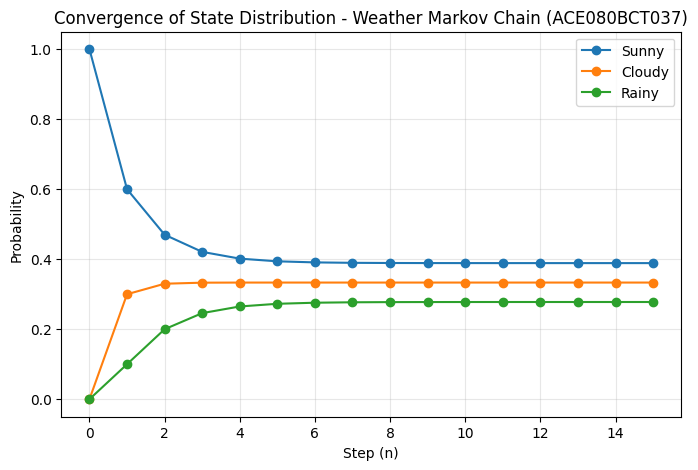


Stationary distribution (after 15 steps): Sunny=0.3889, Cloudy=0.3333, Rainy=0.2778


In [ ]:
plt.figure(figsize=(8, 5))
for i, s in enumerate(states):
    plt.plot(distributions[:, i], marker='o', label=s)
plt.xlabel('Step (n)')
plt.ylabel('Probability')
plt.title('Convergence of State Distribution - Weather Markov Chain (ACE080BCT037)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"\nStationary distribution (after {n_steps} steps): "
      + ", ".join(f"{s}={p:.4f}" for s, p in zip(states, distributions[-1])))


The plot shows that no matter which state the chain starts in, the probability of being in each
state converges to a fixed **stationary distribution** after enough steps — this is the predictive
power that transition probability matrices give us.


---
## Part 2: Markov Decision Processes (MDPs)

### Theory

A **Markov Decision Process** extends a Markov Chain by adding **actions** and **rewards**,
providing a framework for sequential decision-making under uncertainty. An MDP is defined by the
tuple $(S, A, P, R, \gamma)$:

- $S$ : Set of states
- $A$ : Set of actions
- $P(s'\mid s,a)$ : Transition probability of reaching state $s'$ from state $s$ by taking action $a$
- $R(s,a,s')$ : Reward received for that transition
- $\gamma$ : Discount factor

## Q-Learning

Q-learning is a **trial-and-error reinforcement learning algorithm** that learns the long-term
value of actions.

It helps answer the question:

> If the agent is in state $S$ and takes action $A$, how good will that action be in terms of
> future rewards?

### Features
- Trial and error learning
- Learns long-term rewards
- Selects the best action for each state
- Uses a lookup table called the **Q-table**
- Model-free reinforcement learning algorithm

### Mathematical Equation

The Q-learning update rule is:

$$ Q(s,a) \leftarrow Q(s,a) + \alpha \left[ R + \gamma \max_{a'} Q(s', a') - Q(s,a) \right] $$

Where:

**Current Q-value** $Q(s,a)$ — current estimate of the action value.

**Learning Rate** $\alpha$ — determines how much new information replaces the old information.
- $\alpha = 0 \rightarrow$ No learning
- $\alpha = 1 \rightarrow$ Learn completely from the new experience

**Immediate Reward** $R$ — reward (or penalty) received after taking an action.

**Discount Factor** $\gamma$ — determines the importance of future rewards, $0 \le \gamma \le 1$.
- Small $\gamma \rightarrow$ Focus on immediate reward.
- Large $\gamma \rightarrow$ Focus on future reward.

**Next State** $s'$ — the state reached after taking action.

**Best Future Value** $\max_{a'} Q(s', a')$ — maximum expected future reward obtainable from the
next state.


---
## Part 3: Grid-World Q-Learning Simulation

### Setup
We define a $4 \times 4$ grid (16 states, $S_0$ to $S_{15}$), with the agent starting at $S_0$
(top-left) and trying to reach the goal at $S_{15}$ (bottom-right), while avoiding two obstacle
cells at $S_5$ and $S_9$. The agent can move `UP`, `DOWN`, `LEFT`, or `RIGHT`; moves that would
leave the grid simply keep the agent in place.


In [ ]:
import numpy as np
import random
import pandas as pd

GRID_SIZE = 4
N_STATES = GRID_SIZE * GRID_SIZE
ACTIONS = ['UP', 'DOWN', 'LEFT', 'RIGHT']
a_idx = {a: i for i, a in enumerate(ACTIONS)}

START_STATE = 0
GOAL_STATE = 15
OBSTACLES = {5, 9}

def rc_to_state(r, c):
    return r * GRID_SIZE + c

def state_to_rc(s):
    return divmod(s, GRID_SIZE)

def next_state(s, a):
    """Deterministic grid transition; moving off the grid keeps the agent in place."""
    r, c = state_to_rc(s)
    if a == 'UP':
        r = max(0, r - 1)
    elif a == 'DOWN':
        r = min(GRID_SIZE - 1, r + 1)
    elif a == 'LEFT':
        c = max(0, c - 1)
    elif a == 'RIGHT':
        c = min(GRID_SIZE - 1, c + 1)
    return rc_to_state(r, c)

def get_reward(s_next):
    """Reward function R, exactly as defined on the whiteboard."""
    if s_next == GOAL_STATE:
        return 10, True      # +10 (goal) -> end episode
    elif s_next in OBSTACLES:
        return -10, True     # -10 (obstacle) -> end episode
    else:
        return -1, False     # -1 (normal step)

print(f'Grid has {N_STATES} states (S0 - S{N_STATES-1})')
print(f'Start state: S{START_STATE} | Goal state: S{GOAL_STATE} | Obstacles: {sorted(OBSTACLES)}')


Grid has 16 states (S0 - S15)
Start state: S0 | Goal state: S15 | Obstacles: [5, 9]


In [ ]:
# Initial Q-table: rows = states (S0..S15), columns = actions (UP, DOWN, LEFT, RIGHT)
Q = np.zeros((N_STATES, len(ACTIONS)))

initial_q_df = pd.DataFrame(Q, index=[f'S{i}' for i in range(N_STATES)], columns=ACTIONS)
initial_q_df.head()


,UP,DOWN,LEFT,RIGHT
S0,0.0,0.0,0.0,0.0
S1,0.0,0.0,0.0,0.0
S2,0.0,0.0,0.0,0.0
S3,0.0,0.0,0.0,0.0
S4,0.0,0.0,0.0,0.0


### Manual Q-update walkthrough

Before training the agent automatically, we manually trace through a few individual Q-updates to
confirm the update rule behaves as expected. We use $\alpha = 0.5$ and $\gamma = 0.9$.


In [ ]:
ALPHA = 0.5   # learning rate
GAMMA = 0.9   # discount factor

Q_demo = np.zeros((N_STATES, len(ACTIONS)))

def q_update(Q_table, s, a, r, s_next, done):
    best_next = 0 if done else np.max(Q_table[s_next])
    old_value = Q_table[s, a_idx[a]]
    Q_table[s, a_idx[a]] = old_value + ALPHA * (r + GAMMA * best_next - old_value)
    return Q_table[s, a_idx[a]]

# Episode 1: S0 --RIGHT--> S1 (normal), then S1 --DOWN--> S5 (obstacle)
r, done = get_reward(1)
val = q_update(Q_demo, 0, 'RIGHT', r, 1, done)
print(f'Ep1: Q(S0, RIGHT) = {val:.2f}   (expected -0.5)')

r, done = get_reward(5)
val = q_update(Q_demo, 1, 'DOWN', r, 5, done)
print(f'Ep1: Q(S1, DOWN)  = {val:.2f}   (expected -5.0)')

# Episode 2: S0 --DOWN--> S4 (normal)
r, done = get_reward(4)
val = q_update(Q_demo, 0, 'DOWN', r, 4, done)
print(f'Ep2: Q(S0, DOWN)  = {val:.2f}   (expected -0.5)')

# Episode 3: S14 --RIGHT--> S15 (goal!) then back-propagate to S13
r, done = get_reward(15)
val = q_update(Q_demo, 14, 'RIGHT', r, 15, done)
print(f'Ep3: Q(S14, RIGHT) = {val:.2f}   (expected 5.0)')

# Back-propagation: S13 --RIGHT--> S14, now benefits from Q(S14, RIGHT) = 5
r, done = get_reward(14)
val = q_update(Q_demo, 13, 'RIGHT', r, 14, done)
print(f'Ep3: Q(S13, RIGHT) = {val:.2f}   (back-propagated value)')


Ep1: Q(S0, RIGHT) = -0.50   (expected -0.5)
Ep1: Q(S1, DOWN)  = -5.00   (expected -5.0)
Ep2: Q(S0, DOWN)  = -0.50   (expected -0.5)
Ep3: Q(S14, RIGHT) = 5.00   (expected 5.0)
Ep3: Q(S13, RIGHT) = 1.75   (back-propagated value)


### Full Training Loop (Epsilon-Greedy Q-Learning)

Now we train the agent over many episodes using an **epsilon-greedy** action-selection policy:
with probability $\epsilon$ the agent explores (picks a random action), and otherwise it exploits
(picks the currently best-known action).


In [ ]:
EPSILON = 0.2               # exploration rate
N_EPISODES = 500
MAX_STEPS_PER_EPISODE = 50

def choose_action(Q_table, s, epsilon):
    """Epsilon-greedy action selection."""
    if random.random() < epsilon:
        return random.choice(ACTIONS)      # explore
    best_a_idx = np.argmax(Q_table[s])
    return ACTIONS[best_a_idx]             # exploit

def train_q_learning():
    Q_table = np.zeros((N_STATES, len(ACTIONS)))
    rewards_per_episode = []

    for ep in range(N_EPISODES):
        s = START_STATE
        total_reward = 0
        for step in range(MAX_STEPS_PER_EPISODE):
            a = choose_action(Q_table, s, EPSILON)
            s_next = next_state(s, a)
            r, done = get_reward(s_next)
            total_reward += r

            best_next = 0 if done else np.max(Q_table[s_next])
            old_value = Q_table[s, a_idx[a]]
            Q_table[s, a_idx[a]] = old_value + ALPHA * (r + GAMMA * best_next - old_value)

            s = s_next
            if done:
                break
        rewards_per_episode.append(total_reward)

    return Q_table, rewards_per_episode

Q_trained, rewards_history = train_q_learning()
print('Training complete over', N_EPISODES, 'episodes.')


Training complete over 500 episodes.


In [ ]:
final_q_df = pd.DataFrame(np.round(Q_trained, 2),
                           index=[f'S{i}' for i in range(N_STATES)],
                           columns=ACTIONS)
final_q_df


,UP,DOWN,LEFT,RIGHT
S0,0.63,1.77,0.63,1.81
S1,1.81,-10.00,0.63,3.12
S2,3.12,4.58,1.81,4.58
S3,4.58,6.20,3.12,4.58
S4,0.22,3.11,-0.91,-8.75
S5,0.00,0.00,0.00,0.00
S6,1.93,4.19,-7.50,6.20
S7,4.58,8.00,4.58,6.20
S8,-2.31,4.58,-1.85,-9.38
S9,0.00,0.00,0.00,0.00


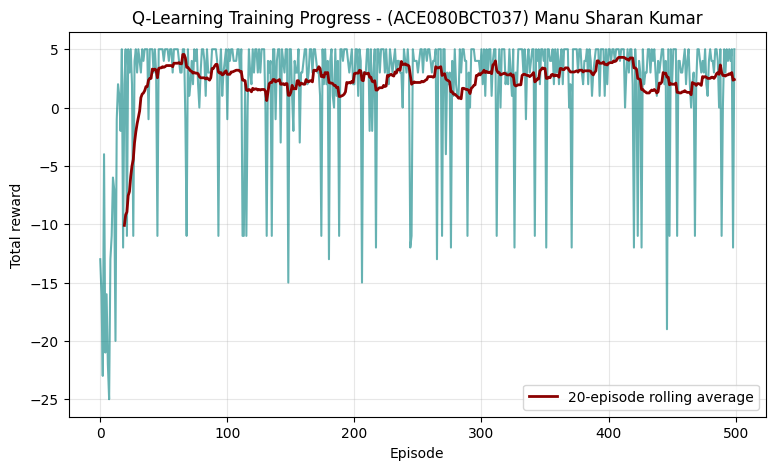

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(rewards_history, color='teal', alpha=0.6)

# Rolling average to show the learning trend more clearly
window = 20
if len(rewards_history) >= window:
    rolling_avg = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
    plt.plot(range(window - 1, len(rewards_history)), rolling_avg, color='darkred',
              linewidth=2, label=f'{window}-episode rolling average')

plt.xlabel('Episode')
plt.ylabel('Total reward')
plt.title('Q-Learning Training Progress - (ACE080BCT037) Manu Sharan Kumar')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
arrow = {'UP': '^', 'DOWN': 'v', 'LEFT': '<', 'RIGHT': '>'}
policy_grid = []
for r in range(GRID_SIZE):
    row = []
    for c in range(GRID_SIZE):
        s = rc_to_state(r, c)
        if s == GOAL_STATE:
            row.append(' G ')
        elif s in OBSTACLES:
            row.append(' X ')
        else:
            best_a = ACTIONS[np.argmax(Q_trained[s])]
            row.append(f' {arrow[best_a]} ')
    policy_grid.append(row)

print('Learned optimal policy (G = goal, X = obstacle):\n')
for row in policy_grid:
    print(' | '.join(row))


Learned optimal policy (G = goal, X = obstacle):

 >  |  >  |  >  |  v 
 v  |  X  |  >  |  v 
 v  |  X  |  v  |  v 
 >  |  >  |  >  |  G 


---
## Discussion

In this lab, the concepts of **Markov Chains**, **Markov Decision Processes (MDPs)**, and
**Q-learning** were studied to understand sequential decision-making under uncertainty. The Markov
Chain demonstrated the **memoryless property**, where the probability of transitioning to the next
state depends only on the current state and not on the previous sequence of states. The transition
probability matrix was used to represent the likelihood of moving between different states, making
it possible to predict future state distributions.

The grid-world simulation then extended this idea into a full MDP: the agent had to choose actions
(not just passively transition between states), and received rewards or penalties depending on the
outcome of each action. Using the epsilon-greedy Q-learning algorithm, the agent gradually learned
a Q-table of action values through trial and error, eventually converging on a policy that
consistently steers it around the obstacle cells ($S_5$, $S_9$) toward the goal ($S_{15}$).

## Conclusion

The Markov Chain provides a mathematical framework for modeling stochastic state transitions,
while the Markov Decision Process extends this concept by incorporating actions and rewards.
Q-learning enables an agent to learn the optimal policy through trial-and-error interactions with
the environment. By repeatedly updating Q-values using the Bellman equation, the agent gradually
discovers the sequence of actions that maximizes long-term cumulative rewards without requiring
prior knowledge of the environment.
